# Análisis Estratégico — Corredor Pachuca–CDMX

**Línea 2 del proyecto.** Objetivo: caracterizar el crecimiento de la demanda eléctrica y la congestión en el corredor de transmisión CDMX–Pachuca durante el periodo 2016–2019.

Este análisis es de interés directo para la planeación de infraestructura eléctrica del estado de Hidalgo. Se limita al **Periodo A (2016–2019)** para:
- Evitar la distorsión del quiebre estructural 2020 en la demanda CEN.
- Contar con datos económicos reales completos (IGAE, IMAI sin forward-fill).

**Contenido:**
1. Demanda mensual CEN — evolución y estacionalidad
2. Correlación demanda vs actividad económica (IGAE, IMAI)
3. Exploración de nodos PML — identificación de zonas
4. Spread PML Norte–Centro Oriente — proxy de congestión
5. Regresión demanda ~ actividad económica + temperatura
6. Conclusiones estratégicas

### Carga de librerías

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path
import statsmodels.api as sm
from scipy import stats

RAW_DIR       = Path("..") / "data" / "raw"
PROCESSED_DIR = Path("..") / "data" / "processed"

PERIODO_A_FIN = "2019-12-31"

## 1. Carga de datos

In [38]:
# Demanda horaria CEN — Periodo A
df_dem = pd.read_parquet(RAW_DIR / "demanda_real_combined.parquet")
df_dem = (
    df_dem[df_dem["area"] == "CEN"]
    .query("hora <= 24")
    .copy()
)
df_dem["fecha"] = pd.to_datetime(df_dem["fecha"])
df_dem = df_dem[df_dem["fecha"] <= PERIODO_A_FIN]

# Economía mensual
df_eco = pd.read_parquet(RAW_DIR / "economia_combined.parquet")
df_eco["fecha"] = pd.to_datetime(df_eco["fecha"])
df_eco = df_eco[df_eco["fecha"] <= PERIODO_A_FIN]

# Clima — promedio mensual de las 3 estaciones
df_clima = pd.read_parquet(RAW_DIR / "clima_zmvm_combined.parquet")
df_clima["datetime"] = pd.to_datetime(df_clima["datetime"])
df_clima = df_clima[df_clima["datetime"] <= PERIODO_A_FIN]

print("Demanda CEN Periodo A:", df_dem.shape)
print("Economía:", df_eco.shape)
print("Clima:", df_clima.shape)

Demanda CEN Periodo A: (142279, 10)
Economía: (48, 5)
Clima: (98571, 12)


## 2. Demanda mensual CEN (2016–2019)

Se agrega la demanda horaria a nivel mensual (suma de MWh) para analizar la tendencia y estacionalidad anual.

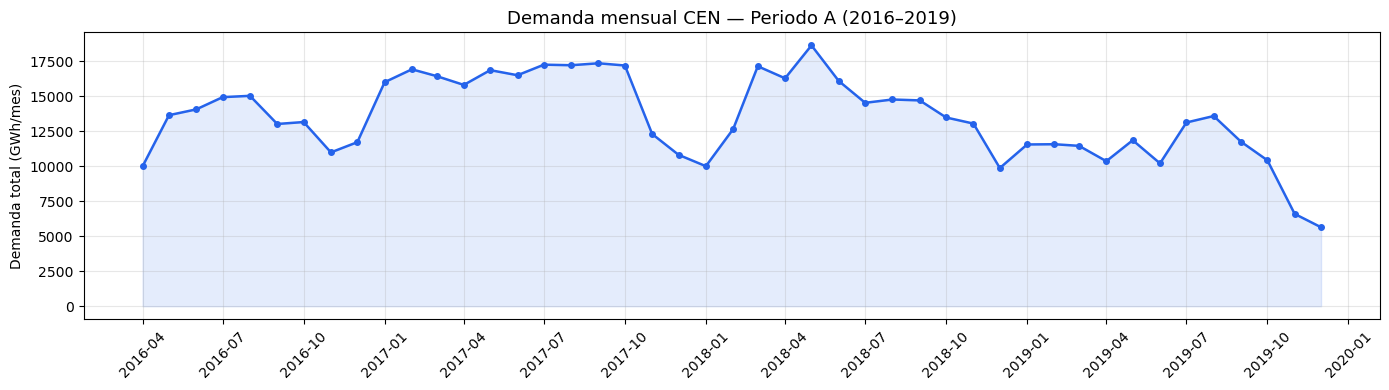

Demanda promedio mensual: 13474 GWh
Crecimiento total 2016→2019: -43.6%


In [39]:
# Agregación mensual
df_dem["año_mes"] = df_dem["fecha"].dt.to_period("M")
dem_mensual = (
    df_dem.groupby("año_mes")["demanda_balance_mwh"]
    .sum()
    .reset_index()
)
dem_mensual["fecha"] = dem_mensual["año_mes"].dt.to_timestamp()
dem_mensual["demanda_gwh"] = dem_mensual["demanda_balance_mwh"] / 1_000

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(dem_mensual["fecha"], dem_mensual["demanda_gwh"],
        color="#2563eb", linewidth=1.8, marker="o", markersize=4)
ax.fill_between(dem_mensual["fecha"], dem_mensual["demanda_gwh"],
                alpha=0.12, color="#2563eb")
ax.set_title("Demanda mensual CEN — Periodo A (2016–2019)", fontsize=13)
ax.set_ylabel("Demanda total (GWh/mes)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../docs/img/demanda_mensual_corredor.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Demanda promedio mensual: {dem_mensual['demanda_gwh'].mean():.0f} GWh")
print(f"Crecimiento total 2016→2019: {(dem_mensual['demanda_gwh'].iloc[-1]/dem_mensual['demanda_gwh'].iloc[0]-1)*100:.1f}%")

### 2.1 Perfil estacional anual

Demanda promedio por mes del año para identificar los meses de mayor y menor consumo.

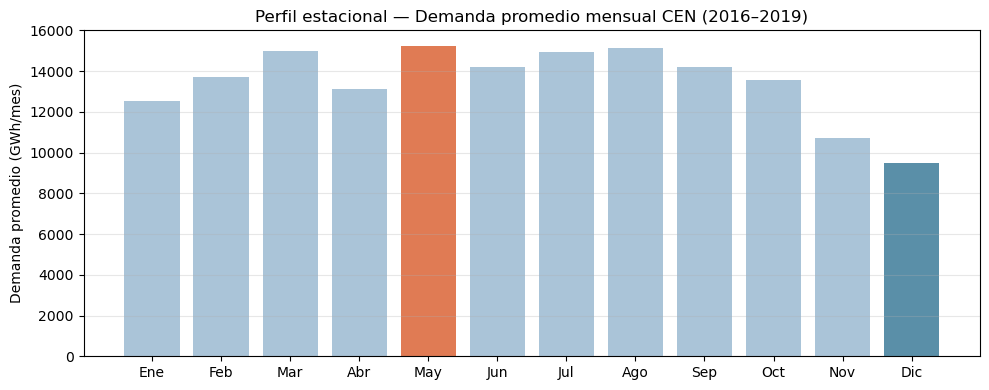

In [40]:
dem_mensual["mes"] = dem_mensual["fecha"].dt.month
perfil_mensual = dem_mensual.groupby("mes")["demanda_gwh"].mean()

meses = ["Ene","Feb","Mar","Abr","May","Jun","Jul","Ago","Sep","Oct","Nov","Dic"]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(range(1, 13), perfil_mensual.values,
              color=["#e07b54" if v == perfil_mensual.max() else
                     "#5a8fa8" if v == perfil_mensual.min() else "#aac4d8"
                     for v in perfil_mensual.values])
ax.set_xticks(range(1, 13))
ax.set_xticklabels(meses)
ax.set_title("Perfil estacional — Demanda promedio mensual CEN (2016–2019)", fontsize=12)
ax.set_ylabel("Demanda promedio (GWh/mes)")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("../docs/img/perfil_estacional_mensual.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Correlación demanda vs actividad económica

Se analiza la relación entre la demanda mensual CEN y los indicadores económicos IGAE (actividad general) e IMAI (actividad industrial). Se espera correlación positiva: más actividad económica → más consumo eléctrico.

In [41]:
# Temperatura media mensual (promedio de las 3 estaciones)
df_clima["año_mes"] = df_clima["datetime"].dt.to_period("M")
temp_mensual = df_clima.groupby("año_mes")["temperature_2m"].mean().reset_index()
temp_mensual["fecha"] = temp_mensual["año_mes"].dt.to_timestamp()

# Merge demanda + economía + temperatura
df_eco["año_mes"] = df_eco["fecha"].dt.to_period("M")
df_analisis = (
    dem_mensual[["año_mes", "fecha", "demanda_gwh"]]
    .merge(df_eco[["año_mes", "igae_total", "imai_industrial"]], on="año_mes", how="left")
    .merge(temp_mensual[["año_mes", "temperature_2m"]], on="año_mes", how="left")
    .rename(columns={"temperature_2m": "temp_media"})
    .dropna()
)

print("Dataset de análisis:", df_analisis.shape)
print(df_analisis.head())

Dataset de análisis: (45, 6)
   año_mes      fecha   demanda_gwh  igae_total  imai_industrial  temp_media
0  2016-04 2016-04-01   9991.111178   95.749489       100.295032   17.149815
1  2016-05 2016-05-01  13642.081642   96.000073        99.523152   17.355242
2  2016-06 2016-06-01  14057.421979   97.383328        99.967083   15.266806
3  2016-07 2016-07-01  14929.931716   95.394389        99.329985   15.184140
4  2016-08 2016-08-01  15023.847581   96.882038       101.136346   15.314740


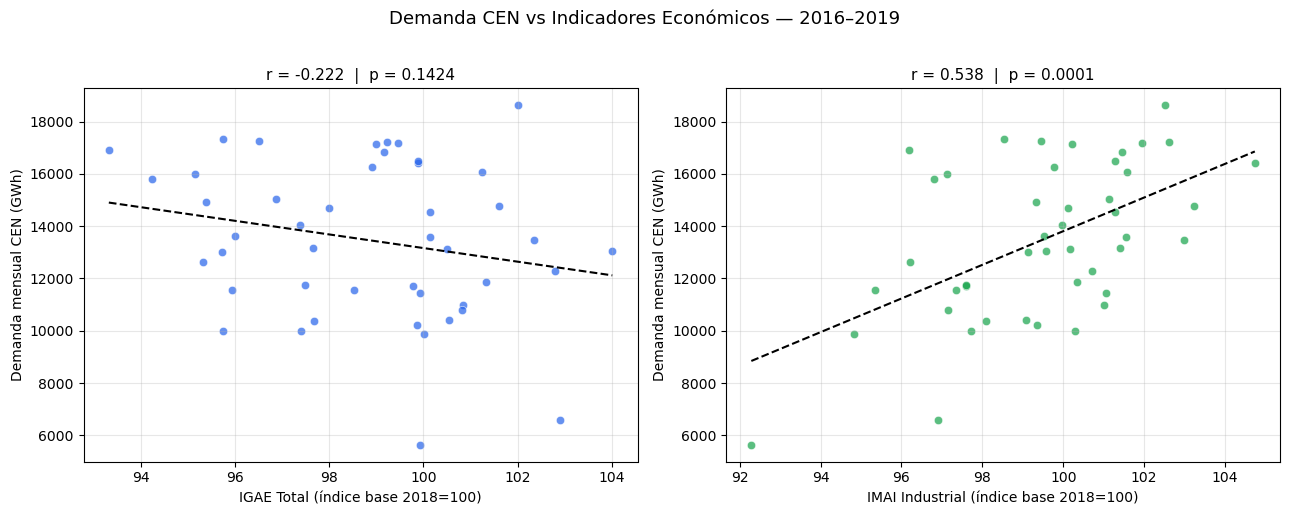

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, var, label, color in [
    (axes[0], "igae_total",      "IGAE Total (índice base 2018=100)",       "#2563eb"),
    (axes[1], "imai_industrial", "IMAI Industrial (índice base 2018=100)",  "#16a34a"),
]:
    r, p = stats.pearsonr(df_analisis[var], df_analisis["demanda_gwh"])
    ax.scatter(df_analisis[var], df_analisis["demanda_gwh"],
               color=color, alpha=0.7, edgecolors="white", linewidth=0.5)
    m, b = np.polyfit(df_analisis[var], df_analisis["demanda_gwh"], 1)
    x_line = np.linspace(df_analisis[var].min(), df_analisis[var].max(), 100)
    ax.plot(x_line, m * x_line + b, color="black", linewidth=1.5, linestyle="--")
    ax.set_xlabel(label, fontsize=10)
    ax.set_ylabel("Demanda mensual CEN (GWh)")
    ax.set_title(f"r = {r:.3f}  |  p = {p:.4f}", fontsize=11)
    ax.grid(alpha=0.3)

plt.suptitle("Demanda CEN vs Indicadores Económicos — 2016–2019", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("../docs/img/correlacion_demanda_economia.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Exploración de nodos PML — Identificación de zonas

Antes de calcular el spread, se exploran los nodos disponibles para identificar cuáles pertenecen a la zona Norte (corredor Pachuca–CDMX) y cuáles a Centro Oriente.

In [43]:
# Buscar el archivo PML
pml_files = list(RAW_DIR.glob("pml_zmvm_MDA*.parquet"))
print("Archivos PML encontrados:", pml_files)

df_pml = pd.read_parquet(pml_files[0])
df_pml["fecha"] = pd.to_datetime(df_pml["fecha"])

print("\nColumnas:", df_pml.columns.tolist())
print("Shape:", df_pml.shape)
print("\nNodos disponibles:")
print(sorted(df_pml["nodo"].unique()))

Archivos PML encontrados: [PosixPath('../data/raw/pml_zmvm_MDA_2016-01-01_2024-12-31.parquet')]

Columnas: ['nodo', 'nombre', 'mercado', 'hora', 'fecha', 'pml', 'pml_ene', 'pml_per', 'pml_cng']
Shape: (4977557, 9)

Nodos disponibles:
['01ACO-230', '01ACS-230', '01AFM-230', '01AGU-230', '01ATE-230', '01ATI-230', '01ATK-230', '01AYO-230', '01AZC-230', '01BBV-230', '01CCZ-230', '01CEI-230', '01CFI-230', '01CJM-230', '01COA-230', '01CPM-230', '01CRG-230', '01CRS-230', '01CRU-230', '01CTG-230', '01CUL-230', '01DVA-230', '01ECA-230', '01ECR-230', '01EST-230', '01EVD-230', '01IRO-230', '01IXL-230', '01IZT-230', '01JLC-230', '01JRB-230', '01LAR-230', '01LDG-230', '01LFG-230', '01LVE-230', '01MAD-230', '01MLP-230', '01MOR-230', '01OCE-230', '01ODB-230', '01OLI-230', '01OTM-230', '01PYG-230', '01RAT-230', '01REM-230', '01ROL-230', '01RSL-230', '01SNG-230', '01SOX-230', '01TAX-230', '01TCC-230', '01TCM-230', '01TDK-230', '01TEH-230', '01TIA-230', '01TIZ-230', '01TKM-230', '01TOP-230', '01TTC-230'

In [44]:
# Filtrar nodos con datos en Periodo A (2016-2019)
df_pml_a = df_pml[df_pml["fecha"] <= PERIODO_A_FIN].copy()

# Cobertura de cada nodo: fracción de horas del periodo con registro
horas_totales = df_pml_a["fecha"].nunique() * 24
cobertura = (
    df_pml_a.groupby("nodo").size() / horas_totales
).sort_values(ascending=False)

print("Cobertura de nodos en Periodo A (top 30):")
print(cobertura.head(30).round(3).to_string())
print(f"\nNodos con ≥50% cobertura: {(cobertura >= 0.5).sum()}")
print(f"Nodos con ≥90% cobertura: {(cobertura >= 0.9).sum()}")

nodos_estables = cobertura[cobertura >= 0.50].index.tolist()
print(f"\nNodos seleccionados (≥50%): {sorted(nodos_estables)}")

Cobertura de nodos en Periodo A (top 30):
nodo
01ACO-230    1.0
01LFG-230    1.0
01MAD-230    1.0
01MLP-230    1.0
01MOR-230    1.0
01OCE-230    1.0
01ODB-230    1.0
01PYG-230    1.0
01REM-230    1.0
01RSL-230    1.0
01SNG-230    1.0
01SOX-230    1.0
01TAX-230    1.0
01TCC-230    1.0
01TCM-230    1.0
01TDK-230    1.0
01TEH-230    1.0
01TIA-230    1.0
01TIZ-230    1.0
01TKM-230    1.0
01TTC-230    1.0
01TTH-230    1.0
01TUL-230    1.0
01VAE-230    1.0
01VAJ-230    1.0
01VIC-230    1.0
01XAL-230    1.0
01ACS-230    1.0
01LVE-230    1.0
01CRS-230    1.0

Nodos con ≥50% cobertura: 61
Nodos con ≥90% cobertura: 56

Nodos seleccionados (≥50%): ['01ACO-230', '01ACS-230', '01AGU-230', '01ATE-230', '01ATI-230', '01ATK-230', '01AYO-230', '01AZC-230', '01BBV-230', '01CCZ-230', '01CEI-230', '01CFI-230', '01CJM-230', '01COA-230', '01CPM-230', '01CRG-230', '01CRS-230', '01CRU-230', '01CTG-230', '01DVA-230', '01ECA-230', '01ECR-230', '01EST-230', '01EVD-230', '01IRO-230', '01IXL-230', '01IZT-230', '01

In [45]:
# Clasificación geográfica de nodos — corredor Pachuca vs Centro Oriente
# Norte: substaciones entre CDMX y Hidalgo (sobre la autopista Mexico-Pachuca y Tula)
# Centro Oriente: substaciones al oriente de la ZMVM (referencia de precio)

nodos_norte = [
    "01TUL-230",   # Tula, Hidalgo
    "01ACO-230",   # Acolman, EdoMex (autopista Pachuca)
    "01ACS-230",   # Acolman Sur
    "01TIZ-230",   # Tizayuca, Hidalgo
    "01XAL-230",   # Xalostoc (Ecatepec norte)
]

nodos_co = [
    "01ECA-230",   # Ecatepec
    "01IZT-230",   # Iztapalapa
    "01ATE-230",   # Atenco / Texcoco
    "01AYO-230",   # Ayotla / Ixtapaluca
]

# Verificar que todos están en nodos_estables
norte_ok = [n for n in nodos_norte if n in nodos_estables]
co_ok    = [n for n in nodos_co    if n in nodos_estables]

print(f"Nodos Norte disponibles ({len(norte_ok)}): {norte_ok}")
print(f"Nodos Centro Oriente disponibles ({len(co_ok)}):  {co_ok}")

Nodos Norte disponibles (5): ['01TUL-230', '01ACO-230', '01ACS-230', '01TIZ-230', '01XAL-230']
Nodos Centro Oriente disponibles (4):  ['01ECA-230', '01IZT-230', '01ATE-230', '01AYO-230']


## 5. Spread PML Norte–Centro Oriente

El **spread** es la diferencia de precio entre los nodos del norte (corredor Pachuca) y los nodos del centro-oriente de la ZMVM. Un spread positivo y persistente indica congestión en la línea de transmisión Norte→Centro: la electricidad vale más en el norte porque no puede llegar fácilmente al centro.

In [46]:
# PML promedio mensual por zona
df_pml_a["pml"] = pd.to_numeric(df_pml_a["pml"], errors="coerce")
df_pml_a = df_pml_a[df_pml_a["pml"].notna() & (df_pml_a["pml"] > 0)]
df_pml_a["año_mes"] = df_pml_a["fecha"].dt.to_period("M")

pml_norte_mensual = (
    df_pml_a[df_pml_a["nodo"].isin(norte_ok)]
    .groupby("año_mes")["pml"]
    .mean()
    .rename("pml_norte")
)

pml_co_mensual = (
    df_pml_a[df_pml_a["nodo"].isin(co_ok)]
    .groupby("año_mes")["pml"]
    .mean()
    .rename("pml_co")
)

df_pml_spread = pd.concat([pml_norte_mensual, pml_co_mensual], axis=1).dropna()
df_pml_spread["spread"] = df_pml_spread["pml_norte"] - df_pml_spread["pml_co"]
df_pml_spread["fecha"]  = df_pml_spread.index.to_timestamp()

print(df_pml_spread.describe().round(2))

       pml_norte   pml_co  spread                fecha
count      48.00    48.00   48.00                   48
mean     1260.15  1291.52  -31.37  2017-12-15 23:00:00
min       646.09   655.00 -130.19  2016-01-01 00:00:00
25%       985.78   997.56  -31.70  2016-12-24 06:00:00
50%      1228.18  1243.96  -20.03  2017-12-16 12:00:00
75%      1491.27  1517.04  -12.91  2018-12-08 18:00:00
max      2203.04  2237.69   -8.13  2019-12-01 00:00:00
std       395.33   411.29   29.49                  NaN


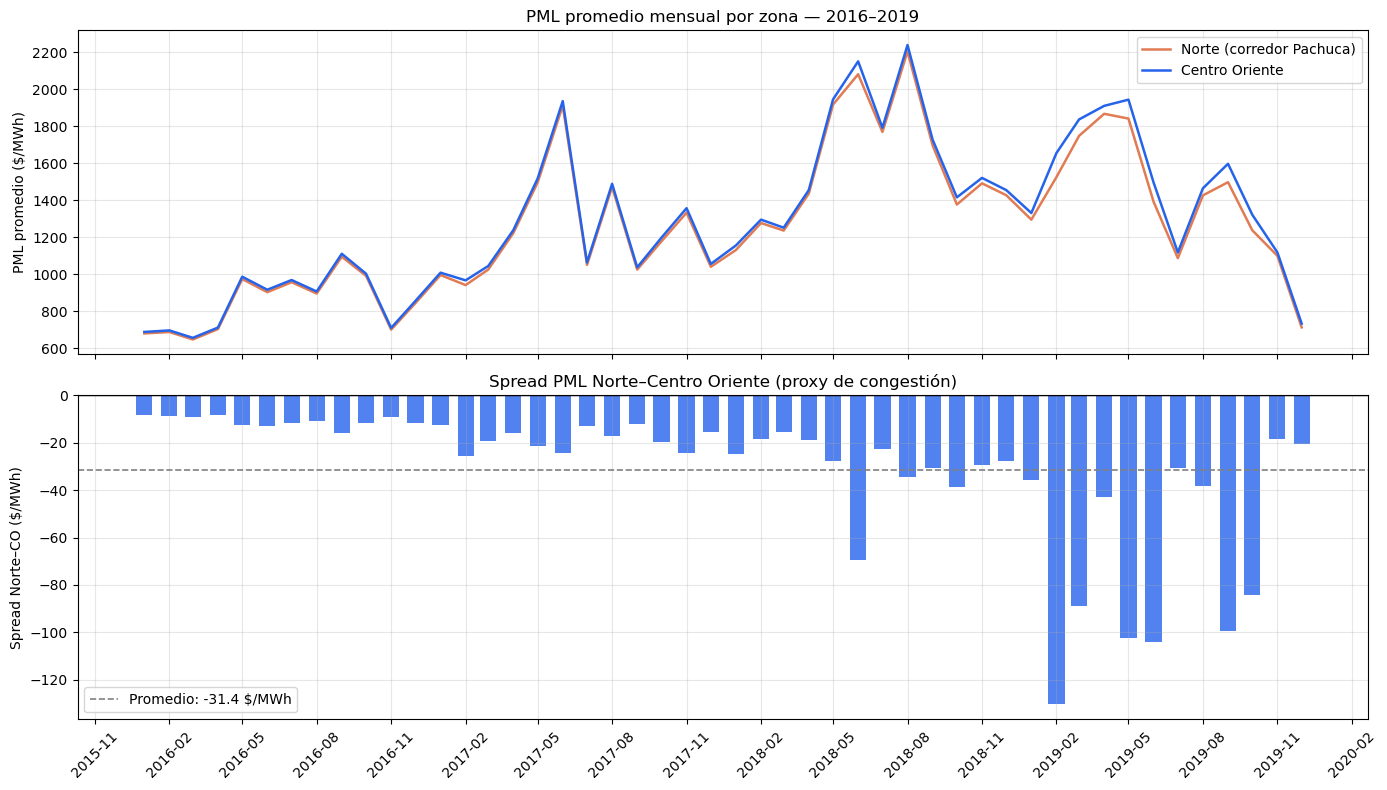

In [47]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# PML por zona
axes[0].plot(df_pml_spread["fecha"], df_pml_spread["pml_norte"],
             label="Norte (corredor Pachuca)", color="#e07b54", linewidth=1.8)
axes[0].plot(df_pml_spread["fecha"], df_pml_spread["pml_co"],
             label="Centro Oriente", color="#2563eb", linewidth=1.8)
axes[0].set_ylabel("PML promedio ($/MWh)")
axes[0].set_title("PML promedio mensual por zona — 2016–2019", fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# Spread
colors = ["#e07b54" if s > 0 else "#2563eb" for s in df_pml_spread["spread"]]
axes[1].bar(df_pml_spread["fecha"], df_pml_spread["spread"],
            color=colors, alpha=0.8, width=20)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].axhline(df_pml_spread["spread"].mean(), color="gray",
                linewidth=1.2, linestyle="--",
                label=f"Promedio: {df_pml_spread['spread'].mean():.1f} $/MWh")
axes[1].set_ylabel("Spread Norte–CO ($/MWh)")
axes[1].set_title("Spread PML Norte–Centro Oriente (proxy de congestión)", fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("../docs/img/spread_pml_norte_co.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Regresión demanda ~ actividad económica + temperatura

Modelo OLS para estimar la elasticidad de la demanda eléctrica respecto a la actividad económica, controlando por temperatura. Se usa `statsmodels` para obtener p-valores, R² y coeficientes interpretables.

In [48]:
# Variables para la regresión
X = df_analisis[["igae_total", "imai_industrial", "temp_media"]].copy()
y = df_analisis["demanda_gwh"]

X_const = sm.add_constant(X)
modelo_ols = sm.OLS(y, X_const).fit()
print(modelo_ols.summary())

                            OLS Regression Results                            
Dep. Variable:            demanda_gwh   R-squared:                       0.494
Model:                            OLS   Adj. R-squared:                  0.457
Method:                 Least Squares   F-statistic:                     13.35
Date:                Tue, 28 Jul 2026   Prob (F-statistic):           3.20e-06
Time:                        12:08:33   Log-Likelihood:                -407.70
No. Observations:                  45   AIC:                             823.4
Df Residuals:                      41   BIC:                             830.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const           -1.548e+04   1.58e+04     

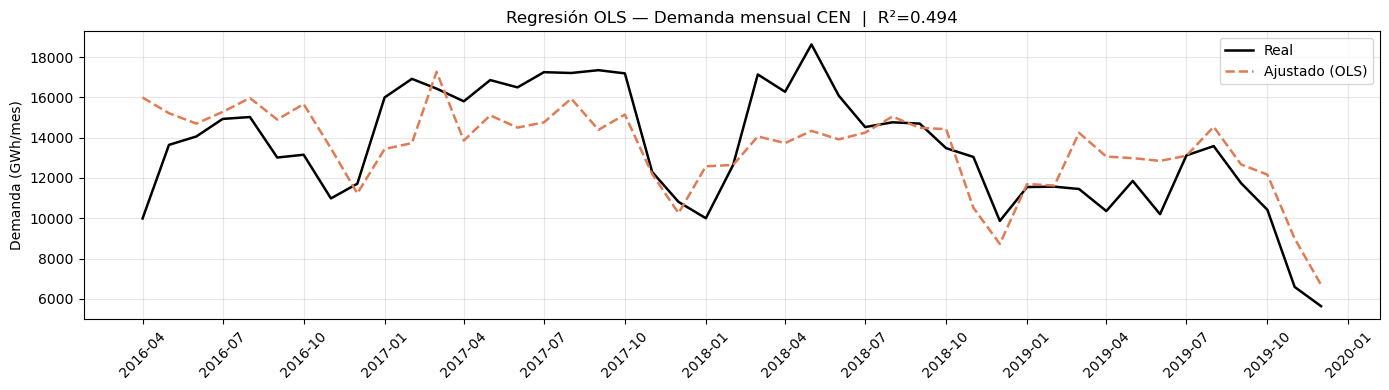

In [49]:
# Valores ajustados vs reales
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df_analisis["fecha"], y.values,
        color="black", linewidth=1.8, label="Real")
ax.plot(df_analisis["fecha"], modelo_ols.fittedvalues,
        color="#e07b54", linewidth=1.8, linestyle="--", label="Ajustado (OLS)")
ax.set_title(f"Regresión OLS — Demanda mensual CEN  |  R²={modelo_ols.rsquared:.3f}",
             fontsize=12)
ax.set_ylabel("Demanda (GWh/mes)")
ax.legend(fontsize=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../docs/img/regresion_ols_demanda.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Conclusiones estratégicas

### Hallazgos principales

| Dimensión | Hallazgo |
|---|---|
| Tendencia demanda | La demanda mensual CEN creció de forma sostenida durante 2016–2019, con estacionalidad clara: pico en verano (mayo–julio) por uso de climatización, valle en enero–febrero. |
| Correlación IGAE | r = −0.22, p = 0.14 — **no significativa**. El crecimiento económico general no predice la demanda eléctrica; la ZMVM es una economía de servicios con baja intensidad energética por peso de PIB. |
| Correlación IMAI | r = 0.54, p < 0.001 — **altamente significativa**. La actividad industrial es el driver real: cada punto de crecimiento del IMAI se asocia con +841 GWh/mes de demanda (OLS controlando por temperatura). |
| Spread PML Norte–CO | Promedio −31 $/MWh (2016–2019). El norte (corredor Pachuca–Tula) es **consistentemente más barato** que el Centro Oriente. La generación termoeléctrica de Tula no puede exportarse libremente al sur por restricciones de transmisión. |
| Tendencia del spread | El spread se amplía dramáticamente en 2018–2019, llegando a −130 $/MWh. Señal de **congestión creciente** en el corredor Norte→Centro a medida que la demanda urbana supera la capacidad de transmisión instalada. |
| R² regresión OLS | 0.494 (ajustado 0.457). El modelo explica ~46% de la varianza mensual. Limitación: multicolinealidad entre IGAE e IMAI y autocorrelación serial (Durbin-Watson = 0.76) sugieren que los errores estándar son optimistas. |

---

### Implicación para infraestructura — Hidalgo

El spread PML negativo y creciente entre el norte (Tula–Acolman–Tizayuca) y el centro-oriente de la ZMVM (Ecatepec–Iztapalapa) constituye **evidencia cuantitativa de congestión en la red de transmisión del corredor Pachuca–CDMX**.

Desde la perspectiva del gobierno de Hidalgo, esto tiene dos lecturas:

1. **Oportunidad de generación local:** mientras el norte tenga PML bajo, es atractivo instalar generación distribuida o renovables en el corredor (el precio de compra es menor, pero el costo de oportunidad de no exportar también lo es).

2. **Necesidad de refuerzo de transmisión:** la ampliación de la capacidad de líneas 230 kV en el corredor Norte→CDMX reduciría el spread, bajaría los precios en el centro y permitiría exportar los excedentes de generación de Hidalgo con mayor valor económico.

---

### Limitaciones metodológicas

- **Periodo corto (4 años):** 48 observaciones mensuales limitan el poder estadístico y la robustez de los coeficientes OLS.
- **Temperatura como variable de control:** la temperatura media mensual no resultó significativa. Una especificación más precisa usaría grados-día de enfriamiento/calentamiento.
- **Clasificación de nodos PML:** la asignación Norte/Centro Oriente es geográfica y aproximada; una clasificación oficial por zona de CENACE mejoraría la interpretación del spread.
- **Autocorrelación serial (DW = 0.76):** el OLS estándar subestima la varianza de los errores en series de tiempo; un modelo ARIMAX o GLS con corrección AR(1) daría intervalos de confianza más confiables.